<a href="https://colab.research.google.com/github/anandhakeerthana-droid/netflix-content-analysis/blob/main/Netflix_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Content Analysis using Python

### Author: Anandhakeerthana K
#### Degree: MSc.Data Science

**Tools Used:** Python, Pandas, NumPy, Matplotlib

**Dataset:** Netflix Movies and TV Shows Dataset (Kaggle)

# Introduction

Netflix is one of the world's largest streaming platforms, offering thousands of movies and TV shows from different countries and across a wide range of genres.

In this project, I performed Exploratory Data Analysis (EDA) on the Netflix Movies and TV Shows dataset using Python. The analysis involved cleaning and preprocessing the data, creating visualizations, and identifying meaningful patterns in Netflix's content library. Through this project, I explored trends related to content types, countries, genres, ratings, directors, movie durations, and the growth of Netflix's catalog over time.


# Project Objective

The objective of this project is to analyze the Netflix Movies and TV Shows dataset using Python and perform Exploratory Data Analysis (EDA) to uncover meaningful insights. The project aims to identify patterns in Netflix's content library by examining content types, countries, genres, ratings, directors, movie durations, and trends in content additions over time. Through this analysis, I also demonstrate fundamental data analysis skills, including data cleaning, preprocessing, visualization, and insight generation.


# Dataset Information

The dataset used in this project is the **Netflix Movies and TV Shows** dataset, obtained from Kaggle. It contains information about the movies and TV shows available on Netflix, with each row representing a single title in the platform's catalog.

The dataset includes details such as:

* Content type (Movie or TV Show)
* Title
* Director and cast
* Country of production
* Date added to Netflix
* Release year
* Content rating
* Duration
* Genre(s)

This dataset is well suited for Exploratory Data Analysis (EDA) because it contains a mix of categorical, numerical, and date-based variables. These features make it possible to explore content distribution, identify trends, compare categories, and generate meaningful business insights through data visualization.


# Import Libraries

The following Python libraries were imported to perform data manipulation, data cleaning, and data visualization throughout this project.


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Dataset

The dataset was loaded into a Pandas DataFrame to prepare it for exploration, cleaning, and analysis.


In [3]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


# Dataset Overview

Before cleaning and analyzing the data, the dataset was explored to understand its structure, identify the available features, and detect any potential data quality issues such as missing values or duplicate records.


In [46]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.columns #column names

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [48]:
df.describe() #summary statistics

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# Data Cleaning

Real-world datasets often contain missing values, duplicate records, inconsistent formatting, and incorrect data types. Before performing any analysis, the dataset was cleaned to improve its quality and ensure accurate results.

The following preprocessing steps were performed:

* Removed duplicate records.
* Handled missing values.
* Filled missing director names with **"Unknown"**.
* Cleaned text columns by removing unnecessary spaces.
* Converted the `date_added` column to datetime format.
* Created a new `year_added` column for time-based analysis.
* Processed multi-value columns such as `country` and `listed_in` using `split()` and `explode()` where required.


In [8]:
df.isnull().sum()
#checking for null values

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['country'] = df['country'].fillna('Unknown') #filling the missing values with'unknown'
df['rating'] = df['rating'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

In [11]:
df = df.dropna(subset=['date_added', 'duration'])

In [12]:
df.isnull().sum() #verifying the cleaning

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


# Exploratory Data Analysis (EDA)

After cleaning and preparing the dataset, exploratory data analysis was performed to identify trends, patterns, and relationships within Netflix's content library. Each analysis below is driven by a business question and supported with an appropriate visualization and insight.


##Analysis 1: Movies vs TV Shows

The Purpose of an Analysis is to answer a **business question**.
The Business Question for the first analysis would potentially be
**"How is Netflix's Content divided between Movies and TV Shows"**

I wanted to start by getting a general understanding of the dataset. Knowing whether Netflix offers more movies or TV shows gives a good overview of the platform before looking into more detailed analyses.

#### What I have done here,
I counted the number of Movies and TV Shows in the `type` column using `value_counts()` and visualized the results with a bar chart and a pie chart.


In [13]:
df['type'].value_counts()

,count
type,
Movie,6128
TV Show,2666


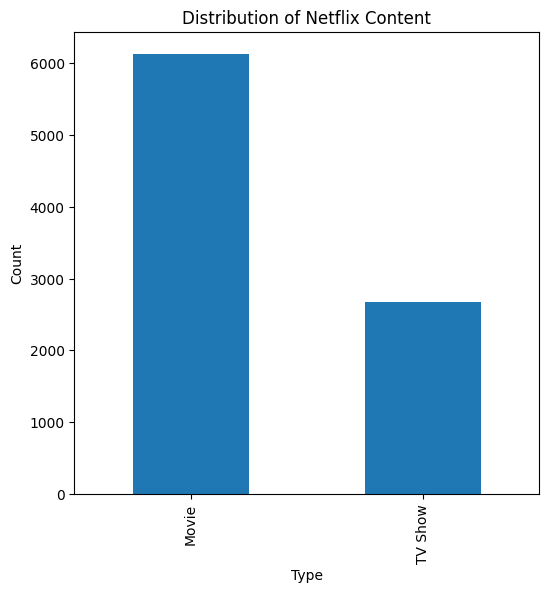

In [47]:
df['type'].value_counts().plot(kind='bar', figsize = (6,6))

plt.title("Distribution of Netflix Content")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

By the above analysis, we have discovered that - Movies account for approximately 70% of Netflix's catalog, while TV Shows make up about 30%. This indicates that Netflix's content library is primarily movie-focused, suggesting a greater emphasis on films than television series.

##Analysis 2: Countries with the Most Netflix Titles

The Business question for our second analysis is,
**"Which countries contribute the most content to Netflix?"**

Since Netflix is available worldwide, I wanted to see which countries contribute the most movies and TV shows to its catalog. This would help me understand where most of Netflix's content comes from.

#### What I have done here,
The `country` column contained multiple countries for some titles, so I split the values, separated them into individual rows using `explode()`, removed extra spaces, counted each country, and displayed the top contributors using a horizontal bar chart.



In [15]:
country_series = df['country'].str.split(',') #split the countries by commas

In [16]:
country_series = country_series.explode() #explode the lists

In [17]:
country_series = country_series.str.strip() #removed the extra spaces

In [18]:
country_counts = country_series.value_counts()

In [19]:
country_counts.head(10)

,count
country,
United States,3681
India,1046
Unknown,830
United Kingdom,805
Canada,445
France,393
Japan,317
Spain,232
South Korea,231


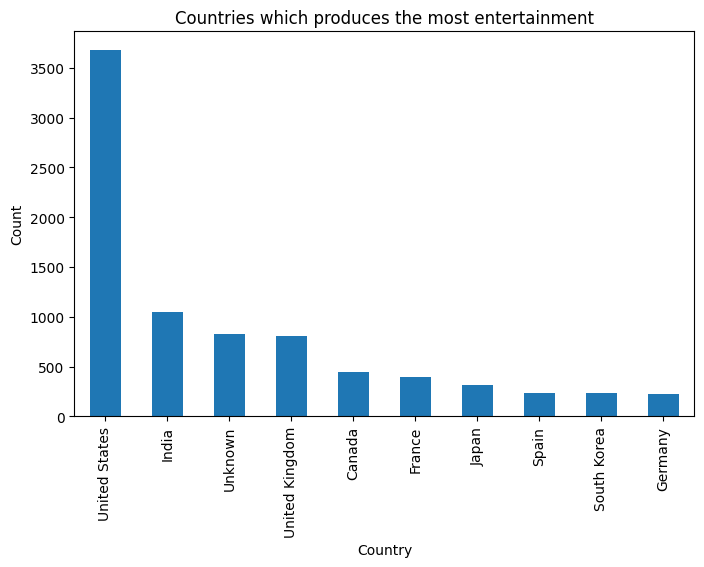

In [20]:
country_counts.head(10).plot(kind='bar',figsize = (8,5))
plt.title("Countries which produces the most entertainment")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

Now I acknowledge that, The United States is the leading contributor to Netflix's catalog by a significant margin. This suggests that Netflix relies heavily on content produced in the U.S., reflecting both the size of the American entertainment industry and Netflix's strong presence in that market.

## Analysis 3: Most Popular Genre

Our next analysis is about **"Which genres appear most frequently in Netflix's catalog?"**

Genres help us understand the type of content Netflix offers. I wanted to find out which genres appear most often and what that says about the platform's overall content.

### What I did,

The `listed_in` column contained multiple genres for many titles, so I split the values, separated them into individual rows, removed extra spaces, counted each genre, and visualized the top genres using a horizontal bar chart.


In [22]:
genre = df['listed_in'].str.split(',')

In [23]:
genre = genre.explode()

In [24]:
genre = genre.str.strip()

In [25]:
genre_count = genre.value_counts()

In [26]:
genre_count.head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1350
Documentaries,869
Action & Adventure,859
TV Dramas,762
Independent Movies,756
Children & Family Movies,641


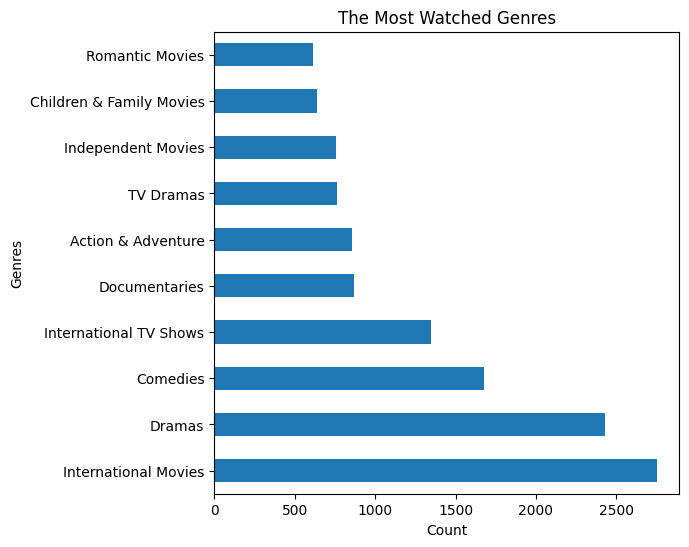

In [27]:
genre_count.head(10).plot(kind='barh', figsize=(6,6))
plt.title("The Most Watched Genres")
plt.xlabel("Count")
plt.ylabel("Genres")
plt.show()

By our 3rd analysis we found that, International Movies is the most common genre in Netflix's catalog. This suggests that Netflix offers a wide variety of international content, reflecting its focus on serving a global audience with diverse viewing preferences.

## Analysis 4: Netflix's Content Growth Over Time


I also wanted to know about the Netflix's content library which brings to my another business question **"How has Netflix's content library grown over the years?"**

I wanted to understand how Netflix expanded its catalog over time and identify the years when the platform added the most content.

### What I did,

I converted the `date_added` column into a datetime format, extracted the year into a new column called `year_added`, counted the number of titles added each year, and visualized the trend using a line chart.


In [28]:
df['date_added'] = df['date_added'].str.strip()

In [29]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [30]:
df['year_added'] = df['date_added'].dt.year

In [31]:
df[['date_added', 'year_added']].head()

,date_added,year_added
0,2021-09-25,2021
1,2021-09-24,2021
2,2021-09-24,2021
3,2021-09-24,2021
4,2021-09-24,2021


In [32]:
df['year_count'] = df['year_added'].value_counts().sort_index()

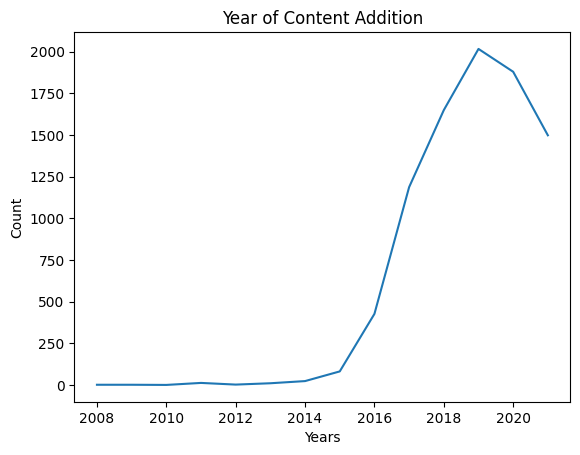

In [33]:
df['year_count'].plot(kind='line')
plt.title("Year of Content Addition")
plt.xlabel("Years")
plt.ylabel("Count")
plt.show()

As we see, The number of titles added to Netflix increased steadily from 2008and reached its highest level around 2019. This indicates that Netflix rapidly expanded its content library during this period, reflecting significant growth in the platform's available content.After the peak, the number of titles added began to decline, suggesting a slowdown in the rate at which new content was added to the platform.

## Analysis 5: Content Ratings

The next analysis answers to the question **"What are the most common content ratings on Netflix?"**

Content ratings help identify the audience that Netflix mainly targets. I wanted to see whether the platform offers more content for children, families, teenagers, or adults.

### What I did here,

I counted the frequency of each value in the `rating` column and displayed the results using a bar chart.



In [34]:
df['rating'].value_counts()

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


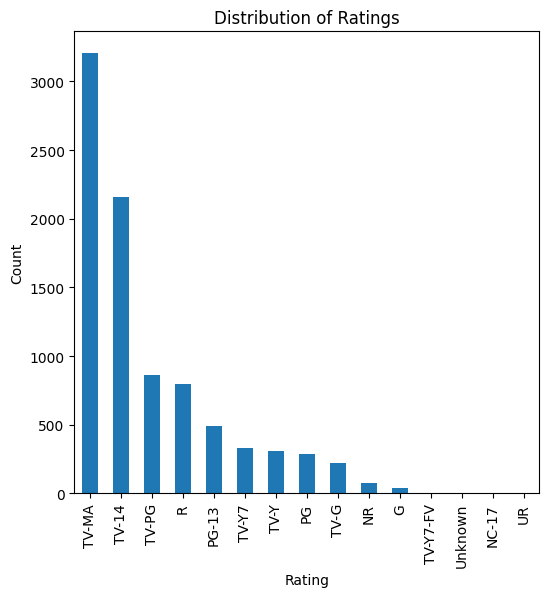

In [35]:
df['rating'].value_counts().plot(kind='bar', figsize = (6,6))
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Clearly, TV-MA is the most common content rating on Netflix, indicating that a significant portion of Netflix's catalog is intended for mature audiences. This suggests that Netflix primarily focuses on providing content for adults rather than young children or family audiences.

## Analysis 6: Genre Comparison Between Movies and TV Shows

After finding the most common genres overall, I wanted to see if Movies and TV Shows followed the same pattern or if each type of content had its own dominant genres.

Which brings me to my next analysis **"Do Movies and TV Shows have different genre distributions on Netflix?"**

### What I did here,

I separated the dataset into Movies and TV Shows using the `type` column. Then, I processed the `listed_in` column by splitting multiple genres, separating them into individual rows, removing extra spaces, and counting the frequency of each genre. Finally, I created horizontal bar charts to compare the top genres for Movies and TV Shows.


In [36]:
movies = df[df['type'] == 'Movie']
tv_shows = df[df['type'] == 'TV Show']

In [37]:
movie_genres = (movies['listed_in'].str.split(',').explode().str.strip().value_counts().head(10))

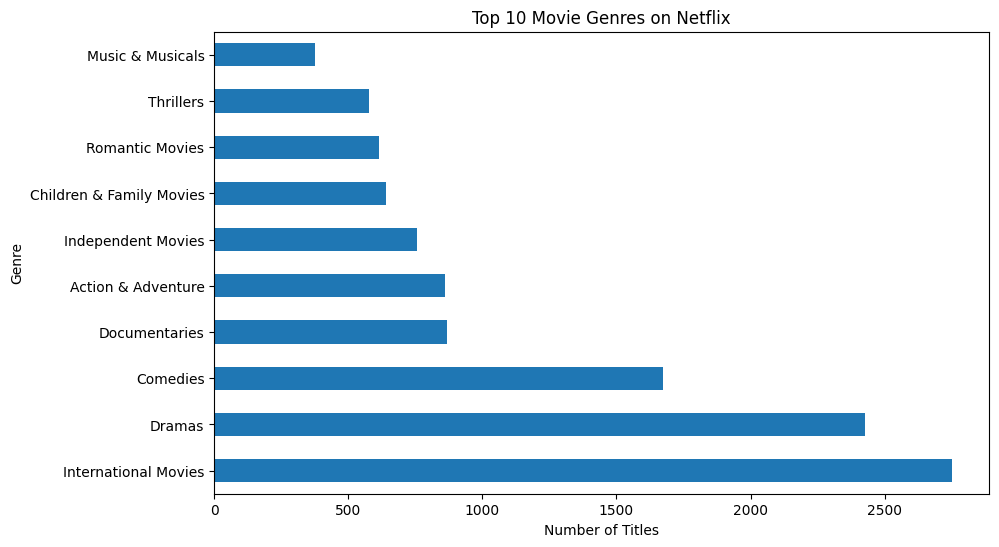

In [38]:
movie_genres.plot(kind='barh', figsize=(10,6))

plt.title("Top 10 Movie Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

In [39]:
tv_genres = (tv_shows['listed_in'].str.split(',').explode().str.strip().value_counts().head(10))

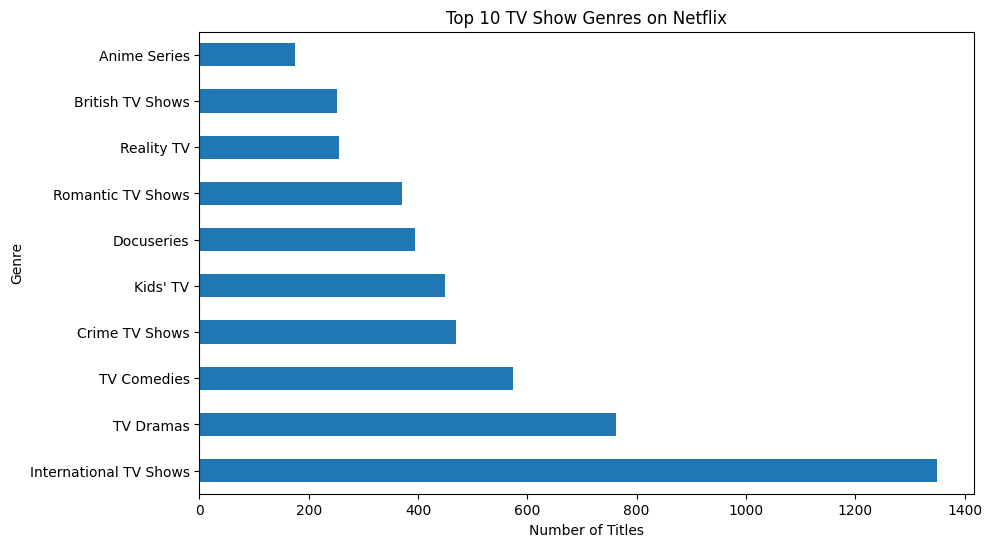

In [40]:
tv_genres.plot(kind='barh', figsize=(10,6))

plt.title("Top 10 TV Show Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

The analysis shows us that, International Movies is the most common genre among movies, while International TV Shows is the most common genre among TV shows. This indicates that Netflix offers a wide variety of international content across both movies and TV shows, reflecting its focus on serving a global audience.

## Analysis 7: Distribution of Movie Durations

And for our final analysis I decided to find out **"What is the typical duration of movies available on Netflix?"**

I wanted to understand the typical length of movies available on Netflix. Analyzing movie durations helps identify whether the platform mainly offers shorter films, standard feature-length movies, or longer productions, giving a better understanding of the overall movie catalog.

### What I did here,

I filtered the dataset to include only movies, extracted the duration in minutes from the `duration` column, converted it into numerical values, and visualized the distribution using a histogram.



In [41]:
movies = df[df['type'] == 'Movie'].copy()

In [42]:
movies['duration_min'] = movies['duration'].str.extract('(\d+)').astype(int)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2585/3362703476.py:1: SyntaxWarning: invalid escape sequence '\d'
  movies['duration_min'] = movies['duration'].str.extract('(\d+)').astype(int)


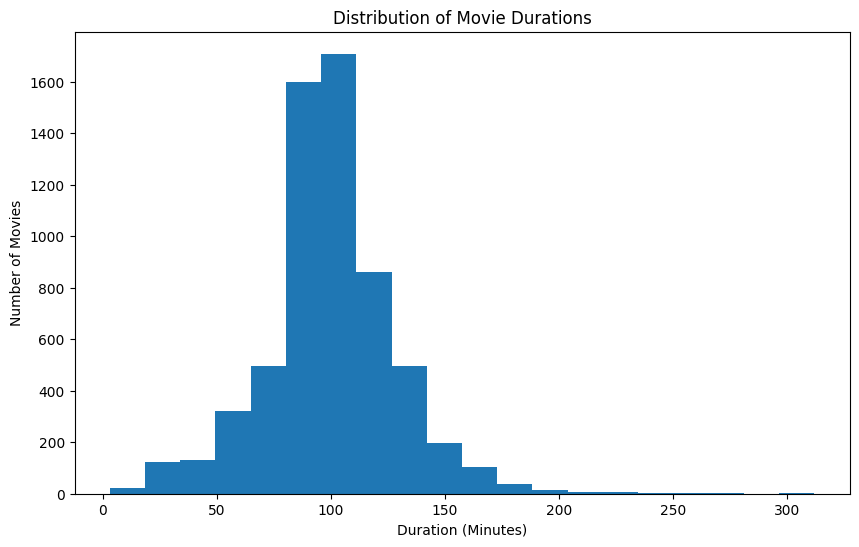

In [43]:
movies['duration_min'].plot(kind='hist', bins=20, figsize=(10,6))

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.show()

That gives our final Insight explaining that, Most movies on Netflix have a duration between 90 and 120 minutes. This suggests that feature-length films dominate Netflix's movie catalog, which aligns with the typical runtime of commercially released movies.

# Project Conclusion

This project explored the Netflix Movies and TV Shows dataset using Python through Exploratory Data Analysis (EDA). After cleaning and preparing the data, I analyzed different aspects of Netflix's content, including content types, countries, genres, ratings, content growth over time, genre distribution, and movie durations.

The analysis revealed that Netflix's catalog is dominated by movies, with the United States contributing the highest number of titles. International content plays a significant role across both movies and TV shows, highlighting Netflix's global reach. The platform also experienced rapid growth in content additions over the years, and most of its content is aimed at mature audiences. Additionally, the majority of movies have a runtime between 90 and 120 minutes, reflecting the standard length of feature films.

Overall, this project demonstrates how exploratory data analysis can be used to uncover meaningful patterns and transform raw data into valuable insights.


# What I Learned

Working on this project helped me understand that data analysis is much more than writing Python code or creating charts. I learned how to approach a dataset by asking meaningful questions, cleaning and preparing the data, choosing appropriate visualizations, and interpreting the results to answer real business questions.

Throughout this project, I strengthened my skills in using Pandas for data manipulation, handling missing values, working with datetime and text data, and creating visualizations with Matplotlib. I also learned the importance of communicating insights clearly, as a good analysis is not just about finding patterns but also about explaining what those patterns mean.

Most importantly, this project gave me confidence in completing an end-to-end exploratory data analysis project—from loading the dataset and cleaning the data to presenting insights in a structured and professional way.  


---
**Thank you for taking the time to explore this project. Feedback and suggestions are always welcome!**